## Imports

In [ ]:
!pip install --upgrade keras
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.4 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.6 MB/s eta 0:00:00


In [ ]:
!apt-get install graphviz
import os
os.environ["PATH"] += os.pathsep + '/path/to/graphviz/bin'

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


In [ ]:
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 6.5 MB/s eta 0:00:00


In [ ]:
import os
import math
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import ops
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K  # Import backend for operations like moments
from tensorflow.keras.initializers import Zeros, Ones
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, MaxPool2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Softmax, Multiply,DepthwiseConv2D, Layer,  GroupNormalization
from tensorflow.keras.models import Model
from keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, LayerNormalization, Embedding, Flatten
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.saving import register_keras_serializable
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
import seaborn as sns
from sklearn.manifold import TSNE
from imblearn.over_sampling import SVMSMOTE
import pickle
from glob import glob

## Hyperparameters

In [ ]:
batch_size = 8
norm_groups = 8  # Number of groups used in GroupNormalization layer
img_size = 256
img_channels = 19
clip_min = -1.0
clip_max = 1.0
BATCH_SIZE = 8
IMG_HEIGHT = IMG_WIDTH = 256
AUTOTUNE = tf.data.AUTOTUNE
image_size = 256
ema = 0.999


## Data loader

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define the file path
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"
grouped_post_optical_file = output_path + "grouped_post_optical.pkl"

# Load the dictionary
with open(grouped_post_optical_file, "rb") as f:
    optical_post_image = pickle.load(f)

# Now you can access the data in the loaded dictionary
print(optical_post_image.keys())

dict_keys(['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7', 'Group 8', 'Group 9'])


In [ ]:
# Define the file path
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"
grouped_topographic_file = output_path + "grouped_topographic.pkl"

# Load the dictionary
with open(grouped_topographic_file, "rb") as f:
    topographic_image = pickle.load(f)

# Now you can access the data in the loaded dictionary
print(topographic_image.keys())

dict_keys(['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7', 'Group 8', 'Group 9'])


In [ ]:
# Define the file path
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"
grouped_masks_file = output_path + "grouped_masks.pkl"

# Load the dictionary
with open(grouped_masks_file, "rb") as f:
    mask = pickle.load(f)
print("Dictionary loaded successfully!")

# For example, to print the keys:
print(mask.keys())

Dictionary loaded successfully!
dict_keys(['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7', 'Group 8', 'Group 9'])


## Process The dataset without augmentation

In [ ]:
# Define the file path
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"
grouped_pre_optical_file = output_path + "grouped_pre_optical.pkl"

# Load the dictionary
with open(grouped_pre_optical_file, "rb") as f:
    optical_pre_image = pickle.load(f)

# Now you can access the data in the loaded dictionary
print(optical_pre_image.keys())

dict_keys(['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7', 'Group 8', 'Group 9'])


In [ ]:
# Define the file path
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"
grouped_pre_optical_file = output_path + "generated_pre_optical.pkl"

# Load the dictionary
with open(grouped_pre_optical_file, "rb") as f:
    optical_pre_image1 = pickle.load(f)

# Now you can access the data in the loaded dictionary
print(optical_pre_image1.keys())

dict_keys(['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7', 'Group 8', 'Group 9'])


In [ ]:
def augment(img, seed):
    """Flips an image left/right randomly based on a seed."""
    # Use the same seed for consistent augmentation
    return tf.image.stateless_random_flip_left_right(img, seed=seed)

def swift(image):
    """Reorders the channels of the image."""
    image = tf.cast(image, tf.float32)
    image = tf.gather(image, [2, 1, 0, 3, 4, 5], axis=-1)
    return image

def combine_data(optical_pre, generated_pre, optical_post, topo, mask, augmentation_threshold=200):
    images_combined = []
    labels = []
    class_names = list(optical_pre.keys())

    for idx, class_name in enumerate(class_names):
        pre_images = optical_pre[class_name]
        gen_pre_images = generated_pre[class_name]
        post_images = optical_post[class_name]
        topo_images = topo[class_name]
        mask_images = mask[class_name]

        # Ensure consistent image counts for all data sources
        assert pre_images.shape[0] == gen_pre_images.shape[0] == post_images.shape[0] == topo_images.shape[0] == mask_images.shape[0], \
            f"Inconsistent image counts for class {class_name}"

        num_images = pre_images.shape[0]

        # Augmentation (if needed)
        if num_images < augmentation_threshold:
            num_augmentations = augmentation_threshold - num_images
            augment_indices = np.random.choice(num_images, num_augmentations, replace=True)

            for i in augment_indices:
                pre_img = pre_images[i]
                gen_pre_img = gen_pre_images[i]
                post_img = post_images[i]
                topo_img = topo_images[i]
                mask_img = mask_images[i]

                # Generate a random seed for consistent augmentation
                seed = tf.random.uniform([2], maxval=100000, dtype=tf.int32)

                # Apply the same augmentation to all images using the same seed
                pre_img_aug = augment(pre_img, seed)
                gen_pre_img_aug = augment(gen_pre_img, seed)
                post_img_aug = augment(post_img, seed)
                topo_img_aug = augment(topo_img, seed)
                mask_img_aug = augment(mask_img, seed)

                # Preprocessing (swift) for augmented images
                pre_img_aug = swift(pre_img_aug)
                gen_pre_img_aug = gen_pre_img_aug
                post_img_aug = swift(post_img_aug)

                # Normalization for augmented images
                pre_img_aug = (pre_img_aug - np.min(pre_img_aug)) / (np.max(pre_img_aug) - np.min(pre_img_aug))
                gen_pre_img_aug = (gen_pre_img_aug - np.min(gen_pre_img_aug)) / (np.max(gen_pre_img_aug) - np.min(gen_pre_img_aug))
                post_img_aug = (post_img_aug - np.min(post_img_aug)) / (np.max(post_img_aug) - np.min(post_img_aug))
                topo_img_aug = (topo_img_aug - np.min(topo_img_aug)) / (np.max(topo_img_aug) - np.min(topo_img_aug))
                mask_img_aug = mask_img_aug

                # Append augmented data
                images_combined.append((pre_img_aug, gen_pre_img_aug, post_img_aug, topo_img_aug, mask_img_aug))
                labels.append(idx)

        # Append original data (with preprocessing and normalization)
        for pre_img, gen_pre_img, post_img, topo_img, mask_img in zip(pre_images, gen_pre_images, post_images, topo_images, mask_images):
            # Preprocessing (swift)
            pre_img = swift(pre_img)
            gen_pre_img = gen_pre_img
            post_img = swift(post_img)

            # Normalization
            pre_img = (pre_img - np.min(pre_img)) / (np.max(pre_img) - np.min(pre_img))
            gen_pre_img = (gen_pre_img - np.min(gen_pre_img)) / (np.max(gen_pre_img) - np.min(gen_pre_img))
            post_img = (post_img - np.min(post_img)) / (np.max(post_img) - np.min(post_img))
            topo_img = (topo_img - np.min(topo_img)) / (np.max(topo_img) - np.min(topo_img))
            mask_img = mask_img

            # Append original data
            images_combined.append((pre_img, gen_pre_img, post_img, topo_img, mask_img))
            labels.append(idx)

    # Split and convert to NumPy arrays
    pre_images = [item[0] for item in images_combined]
    gen_pre_images = [item[1] for item in images_combined]
    post_images = [item[2] for item in images_combined]
    topo_images = [item[3] for item in images_combined]
    mask_images = [item[4] for item in images_combined]

    pre_images = np.array(pre_images)
    gen_pre_images = np.array(gen_pre_images)
    post_images = np.array(post_images)
    topo_images = np.array(topo_images)
    mask_images = np.array(mask_images)
    labels = np.array(labels)

    return (pre_images, gen_pre_images, post_images, topo_images, mask_images), labels
# Combine the dictionaries, including the mask
image_data, labels = combine_data(optical_pre_image, optical_pre_image1,optical_post_image, topographic_image, mask)
# Store original class distribution
unique_classes, class_counts = np.unique(labels, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))

Original Class Counts: {np.int64(0): np.int64(683), np.int64(1): np.int64(200), np.int64(2): np.int64(282), np.int64(3): np.int64(200), np.int64(4): np.int64(200), np.int64(5): np.int64(318), np.int64(6): np.int64(336), np.int64(7): np.int64(403), np.int64(8): np.int64(636)}


In [ ]:
del optical_post_image, optical_pre_image, optical_pre_image1, topographic_image, mask

In [ ]:
print(image_data[0].shape)
print(image_data[1].shape)
print(image_data[2].shape)
print(image_data[3].shape)
print(image_data[4].shape)

(3258, 256, 256, 6)
(3258, 256, 256, 6)
(3258, 256, 256, 6)
(3258, 256, 256, 6)
(3258, 256, 256, 1)


In [ ]:
print(image_data[0].min(), image_data[0].max())
print(image_data[1].min(), image_data[1].max())
print(image_data[2].min(), image_data[2].max())
print(image_data[3].min(), image_data[3].max())

0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0


In [ ]:
# --- Data Splitting and Shuffling ---
from sklearn.model_selection import train_test_split

# Split into training and remaining data (validation + test)
image_train_pre, image_rem_pre, image_train_genpre, image_rem_genpre, image_train_post, image_rem_post, image_train_topo, image_rem_topo, image_train_mask, image_rem_mask, label_train, label_rem = train_test_split(
    image_data[0], image_data[1],image_data[2],image_data[3],image_data[4], labels, train_size=0.75, random_state=42, shuffle=True, stratify=labels)

In [ ]:
# Further split remaining data into validation and test sets
image_valid_pre, image_test_pre, image_valid_genpre, image_test_genpre, image_valid_post, image_test_post, image_valid_topo, image_test_topo, image_valid_mask, image_test_mask, label_valid, label_test = train_test_split(
    image_rem_pre, image_rem_genpre, image_rem_post,image_rem_topo,image_rem_mask, label_rem, train_size=0.6, random_state=42, shuffle=True, stratify=label_rem)

In [ ]:
# Recombine the split data for each image type into tuples
image_train = (image_train_pre, image_train_genpre, image_train_post, image_train_topo, image_train_mask)
image_valid = (image_valid_pre, image_valid_genpre, image_valid_post, image_valid_topo, image_valid_mask)
image_test = (image_test_pre, image_test_genpre, image_test_post, image_test_topo, image_test_mask)

In [ ]:
# Store original class distribution
unique_classes, class_counts = np.unique(label_train, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))
# Store original class distribution
unique_classes, class_counts = np.unique(label_valid, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))
# Store original class distribution
unique_classes, class_counts = np.unique(label_test, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))

Original Class Counts: {np.int64(0): np.int64(512), np.int64(1): np.int64(150), np.int64(2): np.int64(212), np.int64(3): np.int64(150), np.int64(4): np.int64(150), np.int64(5): np.int64(238), np.int64(6): np.int64(252), np.int64(7): np.int64(302), np.int64(8): np.int64(477)}
Original Class Counts: {np.int64(0): np.int64(103), np.int64(1): np.int64(30), np.int64(2): np.int64(42), np.int64(3): np.int64(30), np.int64(4): np.int64(30), np.int64(5): np.int64(48), np.int64(6): np.int64(50), np.int64(7): np.int64(61), np.int64(8): np.int64(95)}
Original Class Counts: {np.int64(0): np.int64(68), np.int64(1): np.int64(20), np.int64(2): np.int64(28), np.int64(3): np.int64(20), np.int64(4): np.int64(20), np.int64(5): np.int64(32), np.int64(6): np.int64(34), np.int64(7): np.int64(40), np.int64(8): np.int64(64)}


In [ ]:
print(image_train[0].min(), image_train[0].max())
print(image_train[1].min(), image_train[1].max())
print(image_train[2].min(), image_train[2].max())
print(image_train[3].min(), image_train[3].max())

0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0


In [ ]:
def compute_indices(img):

    B4, B3, B2, B8, B11, _ = img[..., 0], img[..., 1], img[..., 2], img[..., 3], img[..., 4], img[..., 5]
    # Compute NDVI
    ndvi = (B8 - B4) / (B8 + B4 + 1e-6)
    # Compute NDWI
    ndwi = (B3 - B8) / (B3 + B8 + 1e-6)
    # Compute Brightness Index (BI)
    bi = np.sqrt((B4**2 + B3**2 + B2**2) / 3)
    # Compute BSI
    bsi = ((B4 + B11) - (B2 + B8)) / ((B4 + B11) + (B2 + B8) + 1e-6)
    # Compute SAVI (using L = 0.5)
    savi = ((B8 - B4) * 1.5) / (B8 + B4 + 0.5 + 1e-6)
    # Stack the new indices as additional channels
    img_with_indices = np.dstack([img, ndvi, ndwi, bi, bsi, savi])
    return img_with_indices

In [ ]:
# For gen_image_train_pre
image_train_pre_with_indices = []
for img in image_train_pre:
    img_with_indices = compute_indices(img)
    image_train_pre_with_indices.append(img_with_indices)

image_train_pre = np.array(image_train_pre_with_indices)

# For gen_image_train_pre
image_train_genpre_with_indices = []
for img in image_train_genpre:
    img_with_indices = compute_indices(img)
    image_train_genpre_with_indices.append(img_with_indices)

image_train_genpre = np.array(image_train_genpre_with_indices)

# For gen_image_train_post
image_train_post_with_indices = []
for img in image_train_post:
    img_with_indices = compute_indices(img)
    image_train_post_with_indices.append(img_with_indices)

image_train_post = np.array(image_train_post_with_indices)
print(image_train_pre.shape)
print(image_train_genpre.shape)
print(image_train_post.shape)

(2443, 256, 256, 11)
(2443, 256, 256, 11)
(2443, 256, 256, 11)


In [ ]:
# For gen_image_train_pre
image_valid_pre_with_indices = []
for img in image_valid_pre:
    img_with_indices = compute_indices(img)
    image_valid_pre_with_indices.append(img_with_indices)

image_valid_pre = np.array(image_valid_pre_with_indices)

image_valid_genpre_with_indices = []
for img in image_valid_genpre:
    img_with_indices = compute_indices(img)
    image_valid_genpre_with_indices.append(img_with_indices)

image_valid_genpre = np.array(image_valid_genpre_with_indices)

# For gen_image_train_post
image_valid_post_with_indices = []
for img in image_valid_post:
    img_with_indices = compute_indices(img)
    image_valid_post_with_indices.append(img_with_indices)

image_valid_post = np.array(image_valid_post_with_indices)
print(image_valid_pre.shape)
print(image_valid_genpre.shape)
print(image_valid_post.shape)

(489, 256, 256, 11)
(489, 256, 256, 11)
(489, 256, 256, 11)


In [ ]:
# For gen_image_train_pre
image_test_pre_with_indices = []
for img in image_test_pre:
    img_with_indices = compute_indices(img)
    image_test_pre_with_indices.append(img_with_indices)

image_test_pre = np.array(image_test_pre_with_indices)

image_test_genpre_with_indices = []
for img in image_test_genpre:
    img_with_indices = compute_indices(img)
    image_test_genpre_with_indices.append(img_with_indices)

image_test_genpre = np.array(image_test_genpre_with_indices)

# For gen_image_train_post
image_test_post_with_indices = []
for img in image_test_post:
    img_with_indices = compute_indices(img)
    image_test_post_with_indices.append(img_with_indices)

image_test_post = np.array(image_test_post_with_indices)
print(image_test_pre.shape)
print(image_test_genpre.shape)
print(image_test_post.shape)

(326, 256, 256, 11)
(326, 256, 256, 11)
(326, 256, 256, 11)


In [ ]:
#Normalization of the Dataset between 0 and 1
def normalize_channels(data, channels_to_normalize, nodata_value=np.nan):
    """
    Normalize specific channels of the dataset to a range of 0 to 1.

    Parameters:
    - data: 4D numpy array of shape (num_samples, height, width, num_channels)
    - channels_to_normalize: list of channel indices that need normalization

    Returns:
    - normalized_data: 4D numpy array with normalized channels
    """
    normalized_data = data.copy()

    for i in range(len(normalized_data)):
        for j in channels_to_normalize:
            # Get the channel data
            channel_data = normalized_data[i, :, :, j]
            # Create a mask for valid data (i.e., data that is not nodata)
            valid_mask = ~np.isnan(channel_data) if np.isnan(nodata_value) else (channel_data != nodata_value)
            # Normalize only the valid data
            if np.any(valid_mask):  # Proceed only if there are valid values
                min_val = channel_data[valid_mask].min()
                max_val = channel_data[valid_mask].max()
                # Avoid division by zero if all values in the channel are the same
                range_val = max_val - min_val
                if range_val != 0:
                    channel_data[valid_mask] = (channel_data[valid_mask] - min_val) / range_val
                else:
                    channel_data[valid_mask] = 0  # Set all valid values to 0 if they are constant

            # Assign the normalized channel data back to the array
            normalized_data[i, :, :, j] = channel_data

    return normalized_data

def get_channels_to_normalize(total_channels, exclude_indices):
    """
    Parameters:
    - total_channels: Total number of channels in the dataset.
    - exclude_indices: List of channel indices that should not be normalized.

    Returns:
    - channels_to_normalize: List of channel indices to normalize.
    """
    return [i for i in range(total_channels) if i not in exclude_indices]

In [ ]:
# Example usage:
total_channels = image_train_pre.shape[-1]  # Number of channels in the dataset
exclude_indices = [0,1,2,3,4,5]  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
image_train_pre = normalize_channels(image_train_pre, channels_to_normalize)
image_train_genpre = normalize_channels(image_train_genpre, channels_to_normalize)
image_train_post = normalize_channels(image_train_post, channels_to_normalize)

In [ ]:
# Example usage:
total_channels = image_valid[0].shape[-1]  # Number of channels in the dataset
exclude_indices = [0,1,2,3,4,5]  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
image_valid_pre = normalize_channels(image_valid_pre, channels_to_normalize)
image_valid_genpre = normalize_channels(image_valid_genpre, channels_to_normalize)
image_valid_post = normalize_channels(image_valid_post, channels_to_normalize)

In [ ]:
# Example usage:
total_channels = image_test[0].shape[-1]  # Number of channels in the dataset
exclude_indices = [0,1,2,3,4,5]  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
image_test_pre = normalize_channels(image_test_pre, channels_to_normalize)
image_test_genpre = normalize_channels(image_test_genpre, channels_to_normalize)
image_test_pre = normalize_channels(image_test_post, channels_to_normalize)

In [ ]:
# Recombine the split data for each image type into tuples
image_train = (image_train_pre, image_train_genpre, image_train_post, image_train_topo, image_train_mask)
image_valid = (image_valid_pre, image_valid_genpre, image_valid_post, image_valid_topo, image_valid_mask)
image_test = (image_test_pre, image_test_genpre, image_test_post, image_test_topo, image_test_mask)

In [ ]:
print(image_train[0].min(), image_train[0].max())
print(image_train[1].min(), image_train[1].max())
print(image_train[2].min(), image_train[2].max())
print(image_train[3].min(), image_train[3].max())

0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0


In [ ]:
# Visualise some data
import random
img= random.randint(0, len(image_train[0]))

fig,(ax1,ax2,ax3)= plt.subplots(3,10,figsize=(30,10))

ax3[0].set_title("Post RGB")
ax3[0].title.set_fontsize(20)
ax3[1].set_title("Post NIR")
ax3[1].title.set_fontsize(20)
ax3[2].set_title("Post SWIR1")
ax3[2].title.set_fontsize(20)
ax3[3].set_title("Post SWIR2")
ax3[3].title.set_fontsize(20)
ax3[4].set_title("Post NDVI")
ax3[4].title.set_fontsize(20)
ax3[5].set_title("Post NDWI")
ax3[5].title.set_fontsize(20)
ax3[6].set_title("Post BI")
ax3[6].title.set_fontsize(20)
ax3[7].set_title("Post BSI")
ax3[7].title.set_fontsize(20)
ax3[8].set_title("Post SAVI")
ax3[8].title.set_fontsize(20)
ax3[9].set_title("Mask")
ax3[9].title.set_fontsize(20)
ax3[0].imshow(image_train[2][img, :, :, :3])
ax3[1].imshow(image_train[2][img, :, :, 3])
ax3[2].imshow(image_train[2][img, :, :, 4])
ax3[3].imshow(image_train[2][img, :, :, 5])
ax3[4].imshow(image_train[2][img, :, :, 6])
ax3[5].imshow(image_train[2][img, :, :, 7])
ax3[6].imshow(image_train[2][img, :, :, 8])
ax3[7].imshow(image_train[2][img, :, :, 9])
ax3[8].imshow(image_train[2][img, :, :, 10])
ax3[9].imshow(image_train[4][img, :, :, 0], cmap='gray')
ax3[0].set(xticks=[], yticks=[])
ax3[1].set(xticks=[], yticks=[])
ax3[2].set(xticks=[], yticks=[])
ax3[3].set(xticks=[], yticks=[])
ax3[4].set(xticks=[], yticks=[])
ax3[5].set(xticks=[], yticks=[])
ax3[6].set(xticks=[], yticks=[])
ax3[7].set(xticks=[], yticks=[])
ax3[8].set(xticks=[], yticks=[])
ax3[9].set(xticks=[], yticks=[])
plt.tight_layout()

ax1[0].set_title("Pre RGB")
ax1[0].title.set_fontsize(20)
ax1[1].set_title("Pre NIR")
ax1[1].title.set_fontsize(20)
ax1[2].set_title("Pre SWIR1")
ax1[2].title.set_fontsize(20)
ax1[3].set_title("Pre SWIR2")
ax1[3].title.set_fontsize(20)
ax1[4].set_title("Pre NDVI")
ax1[4].title.set_fontsize(20)
ax1[5].set_title("Pre NDWI")
ax1[5].title.set_fontsize(20)
ax1[6].set_title("Pre BI")
ax1[6].title.set_fontsize(20)
ax1[7].set_title("Pre BSI")
ax1[7].title.set_fontsize(20)
ax1[8].set_title("Pre SAVI")
ax1[8].title.set_fontsize(20)
ax1[9].set_title("DSM+Slope")
ax1[9].title.set_fontsize(20)
ax1[0].imshow(image_train[0][img, :, :, :3])
ax1[1].imshow(image_train[0][img, :, :, 3])
ax1[2].imshow(image_train[0][img, :, :, 4])
ax1[3].imshow(image_train[0][img, :, :, 5])
ax1[4].imshow(image_train[0][img, :, :, 6])
ax1[5].imshow(image_train[0][img, :, :, 7])
ax1[6].imshow(image_train[0][img, :, :, 8])
ax1[7].imshow(image_train[0][img, :, :, 9])
ax1[8].imshow(image_train[0][img, :, :, 10])
ax1[9].imshow(image_train[3][img, :, :, :3])
ax1[0].set(xticks=[], yticks=[])
ax1[1].set(xticks=[], yticks=[])
ax1[2].set(xticks=[], yticks=[])
ax1[3].set(xticks=[], yticks=[])
ax1[4].set(xticks=[], yticks=[])
ax1[5].set(xticks=[], yticks=[])
ax1[6].set(xticks=[], yticks=[])
ax1[7].set(xticks=[], yticks=[])
ax1[8].set(xticks=[], yticks=[])
ax1[9].set(xticks=[], yticks=[])
plt.tight_layout()

ax2[0].set_title("Ada_Pre RGB")
ax2[0].title.set_fontsize(20)
ax2[1].set_title("Ada_Pre NIR")
ax2[1].title.set_fontsize(20)
ax2[2].set_title("Ada_Pre SWIR1")
ax2[2].title.set_fontsize(20)
ax2[3].set_title("Ada_Pre SWIR2")
ax2[3].title.set_fontsize(20)
ax2[4].set_title("Ada_Pre NDVI")
ax2[4].title.set_fontsize(20)
ax2[5].set_title("Ada_Pre NDWI")
ax2[5].title.set_fontsize(20)
ax2[6].set_title("Ada_Pre BI")
ax2[6].title.set_fontsize(20)
ax2[7].set_title("Ada_Pre BSI")
ax2[7].title.set_fontsize(20)
ax2[8].set_title("Ada_Pre SAVI")
ax2[8].title.set_fontsize(20)
ax2[9].set_title("TPWI")
ax2[9].title.set_fontsize(20)
ax2[0].imshow(image_train[1][img, :, :, :3])
ax2[1].imshow(image_train[1][img, :, :, 3])
ax2[2].imshow(image_train[1][img, :, :, 4])
ax2[3].imshow(image_train[1][img, :, :, 5])
ax2[4].imshow(image_train[1][img, :, :, 6])
ax2[5].imshow(image_train[1][img, :, :, 7])
ax2[6].imshow(image_train[1][img, :, :, 8])
ax2[7].imshow(image_train[1][img, :, :, 9])
ax2[8].imshow(image_train[1][img, :, :, 10])
ax2[9].imshow(image_train[3][img, :, :, 5:6])
ax2[0].set(xticks=[], yticks=[])
ax2[1].set(xticks=[], yticks=[])
ax2[2].set(xticks=[], yticks=[])
ax2[3].set(xticks=[], yticks=[])
ax2[4].set(xticks=[], yticks=[])
ax2[5].set(xticks=[], yticks=[])
ax2[6].set(xticks=[], yticks=[])
ax2[7].set(xticks=[], yticks=[])
ax2[8].set(xticks=[], yticks=[])
ax2[9].set(xticks=[], yticks=[])
plt.tight_layout()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_pre_train.npy", image_train[0])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_pre_val.npy", image_valid[0])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_pre_test.npy", image_test[0])

In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_genpre_train.npy", image_train[1])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_genpre_val.npy", image_valid[1])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_genpre_test.npy", image_test[1])

In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_post_train.npy", image_train[2])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_post_val.npy", image_valid[2])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_post_test.npy", image_test[2])

In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_topo_train.npy", image_train[3])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_topo_val.npy", image_valid[3])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_topo_test.npy", image_test[3])

In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Y_mask_train.npy", image_train[4])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Y_mask_val.npy", image_valid[4])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Y_mask_test.npy", image_test[4])

In [ ]:
# Assuming 'label_train', 'label_valid', and 'label_test' are your label arrays
np.save("/content/drive/MyDrive/landslide/Data/Arrays/label_train.npy", label_train)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/label_valid.npy", label_valid)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/label_test.npy", label_test)

## Process The dataset with augmentation

In [ ]:
# Define the file path
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"
grouped_pre_optical_file = output_path + "generated_pre_optical.pkl"

# Load the dictionary
with open(grouped_pre_optical_file, "rb") as f:
    optical_pre_image = pickle.load(f)

# Now you can access the data in the loaded dictionary
print(optical_pre_image.keys())

dict_keys(['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7', 'Group 8', 'Group 9'])


In [ ]:
def filter_rois_by_sample_count(image_dict, max_samples=400):
    filtered_rois = {roi_name: roi_array for roi_name, roi_array in image_dict.items() if roi_array.shape[0] < max_samples}
    remaining_rois = {roi_name: roi_array for roi_name, roi_array in image_dict.items() if roi_array.shape[0] >= max_samples}
    return filtered_rois, remaining_rois

# Apply the filter and get both sets of ROIs
optical_post_image, remaining_optical_post = filter_rois_by_sample_count(optical_post_image)
optical_pre_image, remaining_optical_pre = filter_rois_by_sample_count(optical_pre_image)
topographic_image, remaining_topographic = filter_rois_by_sample_count(topographic_image)
mask, remaining_mask = filter_rois_by_sample_count(mask)

In [ ]:
print(f"Filtered Optical ROIs: {list(optical_post_image.keys())}")
total_patches1 = sum(val.shape[0] for val in optical_post_image.values())
print("Total patches in image_list1:", total_patches1)
print(f"Remaining Optical ROIs: {list(remaining_optical_post.keys())}")
total_patches2 = sum(val.shape[0] for val in remaining_optical_post.values())
print("Total patches in remaining_image_list1:", total_patches2)

Filtered Optical ROIs: ['Group 2', 'Group 3', 'Group 4', 'Group 5', 'Group 6', 'Group 7']
Total patches in image_list1: 1329
Remaining Optical ROIs: ['Group 0', 'Group 8', 'Group 9']
Total patches in remaining_image_list1: 1722


In [ ]:
def augment(img, seed):
    """Flips an image left/right randomly."""
    return tf.image.stateless_random_flip_left_right(img, seed=seed)

def swift(image):
    image = tf.cast(image, tf.float32)
    image = tf.gather(image, [2, 1, 0, 3, 4, 5], axis=-1)
    return image

def combine_data(optical_pre, optical_post, topo, mask, augmentation_threshold=200):
    images_combined = []
    labels = []
    class_names = list(optical_pre.keys())

    for idx, class_name in enumerate(class_names):
        pre_images = optical_pre[class_name]
        post_images = optical_post[class_name]
        topo_images = topo[class_name]
        mask_images = mask[class_name]

        # Ensure all dictionaries have the same number of images per class
        assert pre_images.shape[0] == post_images.shape[0] == topo_images.shape[0] == mask_images.shape[0], \
            f"Inconsistent image counts for class {class_name}"

        num_images = pre_images.shape[0]

        # If the number of images is less than the threshold, augment the data
        if num_images < augmentation_threshold:
            # Calculate how many additional images are needed
            num_augmentations = augmentation_threshold - num_images

            # Randomly select images to augment
            augment_indices = np.random.choice(num_images, num_augmentations, replace=True)

            # Augment the selected images
            for i in augment_indices:
                pre_img = pre_images[i]
                post_img = post_images[i]
                topo_img = topo_images[i]
                mask_img = mask_images[i]

                # Generate a random seed for consistent augmentation
                seed = tf.random.uniform([2], maxval=100000, dtype=tf.int32)

                # Apply the same augmentation to all images using the same seed
                pre_img_aug = augment(pre_img, seed)
                post_img_aug = augment(post_img, seed)
                topo_img_aug = augment(topo_img, seed)
                mask_img_aug = augment(mask_img, seed)

                #swift and compute indices for both the augmented and original images BEFORE normalization
                post_img_aug = swift(post_img_aug)

                # Normalize augmented images to the range [-1, 1]
                pre_img_aug = (pre_img_aug - np.min(pre_img_aug)) / (np.max(pre_img_aug) - np.min(pre_img_aug))
                post_img_aug = (post_img_aug - np.min(post_img_aug)) / (np.max(post_img_aug) - np.min(post_img_aug))
                topo_img_aug = (topo_img_aug - np.min(topo_img_aug)) / (np.max(topo_img_aug) - np.min(topo_img_aug))
                mask_img_aug = mask_img_aug


                # Append the augmented images to the dataset
                images_combined.append((pre_img_aug, post_img_aug, topo_img_aug, mask_img_aug))
                labels.append(idx)

        # Append the original images to the dataset
        for pre_img, post_img, topo_img, mask_img in zip(pre_images, post_images, topo_images, mask_images):
            #swift and compute indices for both the augmented and original images BEFORE normalization
            post_img = swift(post_img)

            # Normalize original images to the range [-1, 1]
            pre_img = (pre_img - np.min(pre_img)) / (np.max(pre_img) - np.min(pre_img))
            post_img = (post_img - np.min(post_img)) / (np.max(post_img) - np.min(post_img))
            topo_img = (topo_img - np.min(topo_img)) / (np.max(topo_img) - np.min(topo_img))
            mask_img = mask_img

            images_combined.append((pre_img, post_img, topo_img, mask_img))
            labels.append(idx)

    # Split the combined data into separate lists
    pre_images = [item[0] for item in images_combined]
    post_images = [item[1] for item in images_combined]
    topo_images = [item[2] for item in images_combined]
    mask_images = [item[3] for item in images_combined]

    # Convert each list to a NumPy array
    pre_images = np.array(pre_images)
    post_images = np.array(post_images)
    topo_images = np.array(topo_images)
    mask_images = np.array(mask_images)
    labels = np.array(labels)

    return (pre_images, post_images, topo_images, mask_images), labels
# Combine the dictionaries, including the mask
image_data, labels = combine_data(optical_pre_image, optical_post_image, topographic_image, mask)
remaining_image_data, remaining_labels = combine_data(remaining_optical_pre, remaining_optical_post, remaining_topographic, remaining_mask)
# Store original class distribution
unique_classes, class_counts = np.unique(labels, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))
# Store original class distribution
unique_classes, class_counts = np.unique(remaining_labels, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))

Original Class Counts: {np.int64(0): np.int64(200), np.int64(1): np.int64(282), np.int64(2): np.int64(200), np.int64(3): np.int64(200), np.int64(4): np.int64(318), np.int64(5): np.int64(336)}
Original Class Counts: {np.int64(0): np.int64(683), np.int64(1): np.int64(403), np.int64(2): np.int64(636)}


In [ ]:
print(image_data[0].shape)
print(image_data[1].shape)
print(image_data[2].shape)
print(image_data[3].shape)
print(labels.shape)

(1536, 256, 256, 6)
(1536, 256, 256, 6)
(1536, 256, 256, 6)
(1536, 256, 256, 1)
(1536,)


In [ ]:
print(image_data[0].min(), image_data[0].max())
print(image_data[1].min(), image_data[1].max())
print(image_data[2].min(), image_data[2].max())
print(image_data[3].min(), image_data[3].max())

0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0


In [ ]:
# Visualise some data
import random
img= random.randint(0, len(image_data[0]))

fig,(ax1,ax2)= plt.subplots(2,4,figsize=(30,10))

ax1[0].set_title("Post RGB")
ax1[0].title.set_fontsize(20)
ax1[1].set_title("Post NIR")
ax1[1].title.set_fontsize(20)
ax1[2].set_title("Post SWIR1")
ax1[2].title.set_fontsize(20)
ax1[3].set_title("Post SWIR2")
ax1[3].title.set_fontsize(20)
ax1[0].imshow(image_data[0][img, :, :, :3])
ax1[1].imshow(image_data[0][img, :, :, 3])
ax1[2].imshow(image_data[0][img, :, :, 4])
ax1[3].imshow(image_data[0][img, :, :, 5])
ax1[0].set(xticks=[], yticks=[])
ax1[1].set(xticks=[], yticks=[])
ax1[2].set(xticks=[], yticks=[])
ax1[3].set(xticks=[], yticks=[])
plt.tight_layout()

ax2[0].set_title("Pre RGB")
ax2[0].title.set_fontsize(20)
ax2[1].set_title("Pre NIR")
ax2[1].title.set_fontsize(20)
ax2[2].set_title("Pre SWIR1")
ax2[2].title.set_fontsize(20)
ax2[3].set_title("Pre SWIR2")
ax2[3].title.set_fontsize(20)
ax2[0].imshow(image_data[1][img, :, :, :3])
ax2[1].imshow(image_data[1][img, :, :, 3])
ax2[2].imshow(image_data[1][img, :, :, 4])
ax2[3].imshow(image_data[1][img, :, :, 5])
ax2[0].set(xticks=[], yticks=[])
ax2[1].set(xticks=[], yticks=[])
ax2[2].set(xticks=[], yticks=[])
ax2[3].set(xticks=[], yticks=[])
plt.tight_layout()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Visualise some data
import random
img= random.randint(0, len(image_data[0]))

fig,(ax1,ax2)= plt.subplots(2,4,figsize=(30,10))

ax1[0].set_title("Post RGB")
ax1[0].title.set_fontsize(20)
ax1[1].set_title("Post NIR")
ax1[1].title.set_fontsize(20)
ax1[2].set_title("Post SWIR1")
ax1[2].title.set_fontsize(20)
ax1[3].set_title("Post SWIR2")
ax1[3].title.set_fontsize(20)
ax1[0].imshow(remaining_image_data[0][img, :, :, :3])
ax1[1].imshow(remaining_image_data[0][img, :, :, 3])
ax1[2].imshow(remaining_image_data[0][img, :, :, 4])
ax1[3].imshow(remaining_image_data[0][img, :, :, 5])
ax1[0].set(xticks=[], yticks=[])
ax1[1].set(xticks=[], yticks=[])
ax1[2].set(xticks=[], yticks=[])
ax1[3].set(xticks=[], yticks=[])
plt.tight_layout()

ax2[0].set_title("Pre RGB")
ax2[0].title.set_fontsize(20)
ax2[1].set_title("Pre NIR")
ax2[1].title.set_fontsize(20)
ax2[2].set_title("Pre SWIR1")
ax2[2].title.set_fontsize(20)
ax2[3].set_title("Pre SWIR2")
ax2[3].title.set_fontsize(20)
ax2[0].imshow(remaining_image_data[1][img, :, :, :3])
ax2[1].imshow(remaining_image_data[1][img, :, :, 3])
ax2[2].imshow(remaining_image_data[1][img, :, :, 4])
ax2[3].imshow(remaining_image_data[1][img, :, :, 5])
ax2[0].set(xticks=[], yticks=[])
ax2[1].set(xticks=[], yticks=[])
ax2[2].set(xticks=[], yticks=[])
ax2[3].set(xticks=[], yticks=[])
plt.tight_layout()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# --- Data Splitting and Shuffling ---
from sklearn.model_selection import train_test_split
# Split into training and remaining data (validation + test)
image_train_pre, image_rem_pre, image_train_post, image_rem_post, image_train_topo, image_rem_topo, image_train_mask, image_rem_mask, label_train, label_rem = train_test_split(
    image_data[0], image_data[1],image_data[2],image_data[3], labels, train_size=0.75, random_state=42, shuffle=True, stratify=labels)
remaining_train_pre, remaining_rem_pre, remaining_train_post, remaining_rem_post, remaining_train_topo, remaining_rem_topo, remaining_train_mask, remaining_rem_mask, remaining_label_train, remaining_label_rem = train_test_split(
    remaining_image_data[0], remaining_image_data[1],remaining_image_data[2],remaining_image_data[3], remaining_labels, train_size=0.75, random_state=42, shuffle=True, stratify=remaining_labels)

In [ ]:
# Further split remaining data into validation and test sets
image_valid_pre, image_test_pre, image_valid_post, image_test_post, image_valid_topo, image_test_topo, image_valid_mask, image_test_mask, label_valid, label_test = train_test_split(
    image_rem_pre, image_rem_post,image_rem_topo,image_rem_mask, label_rem, train_size=0.6, random_state=42, shuffle=True, stratify=label_rem)
remaining_valid_pre, remaining_test_pre, remaining_valid_post, remaining_test_post, remaining_valid_topo, remaining_test_topo, remaining_valid_mask, remaining_test_mask, remaining_label_valid, remaining_label_test = train_test_split(
    remaining_rem_pre, remaining_rem_post,remaining_rem_topo,remaining_rem_mask, remaining_label_rem, train_size=0.6, random_state=42, shuffle=True, stratify=remaining_label_rem)

In [ ]:
# Store original class distribution
unique_classes, class_counts = np.unique(label_train, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))
# Store original class distribution
unique_classes, class_counts = np.unique(label_valid, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))
# Store original class distribution
unique_classes, class_counts = np.unique(label_test, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))

unique_classes, class_counts = np.unique(remaining_label_train, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))
# Store original class distribution
unique_classes, class_counts = np.unique(remaining_label_valid, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))
# Store original class distribution
unique_classes, class_counts = np.unique(remaining_label_test, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))

Original Class Counts: {np.int64(0): np.int64(150), np.int64(1): np.int64(211), np.int64(2): np.int64(150), np.int64(3): np.int64(150), np.int64(4): np.int64(239), np.int64(5): np.int64(252)}
Original Class Counts: {np.int64(0): np.int64(30), np.int64(1): np.int64(43), np.int64(2): np.int64(30), np.int64(3): np.int64(30), np.int64(4): np.int64(47), np.int64(5): np.int64(50)}
Original Class Counts: {np.int64(0): np.int64(20), np.int64(1): np.int64(28), np.int64(2): np.int64(20), np.int64(3): np.int64(20), np.int64(4): np.int64(32), np.int64(5): np.int64(34)}
Original Class Counts: {np.int64(0): np.int64(512), np.int64(1): np.int64(302), np.int64(2): np.int64(477)}
Original Class Counts: {np.int64(0): np.int64(102), np.int64(1): np.int64(61), np.int64(2): np.int64(95)}
Original Class Counts: {np.int64(0): np.int64(69), np.int64(1): np.int64(40), np.int64(2): np.int64(64)}


In [ ]:
del optical_post_image, optical_pre_image, topographic_image, mask, remaining_optical_post, remaining_optical_pre, remaining_topographic, remaining_mask

In [ ]:
# Ensure correct concatenation along last axis (channel-wise stacking)
images = np.concatenate((image_train_pre, image_train_post, image_train_topo, image_train_mask), axis=-1)  # Shape: (samples, H, W, C)
flattened_images = images.reshape(images.shape[0], -1)  # Flatten for t-SNE and SMOTE
print("shape", images.shape)

shape (1152, 256, 256, 19)


In [ ]:
del image_data, labels, remaining_image_data, remaining_labels

In [ ]:
# Define the number of images we want for each class (total after SMOTE)
desired_samples_per_class = {
    0: 220,  # Example: Increase class 0 to 200 images
    1: 260,  # Example: Increase class 1 to 250 images
    2: 220,  # Example: Increase class 2 to 180 images
    3: 220,  # Example: Increase class 0 to 200 images
    4: 270,  # Example: Increase class 1 to 250 images
    5: 290,  # Example: Increase class 2 to 180 images
}
original_size = len(label_train)

# Apply SMOTE with controlled sampling strategy
smote = SVMSMOTE(sampling_strategy=desired_samples_per_class, random_state=42)
oversampled_images, oversampled_labels = smote.fit_resample(flattened_images, label_train)

# Identify the synthetic samples (newly added samples after SMOTE)
synthetic_indices = np.arange(original_size, len(oversampled_labels))  # Indices of new synthetic images
# Extract synthetic images
synthetic_images = oversampled_images[synthetic_indices]  # Select only synthetic samples
synthetic_labels = oversampled_labels[synthetic_indices]  # Corresponding labels

# Reshape synthetic images back to (H, W, C)
num_channels = images.shape[-1]
synthetic_images_reshaped = synthetic_images.reshape(-1, images.shape[1], images.shape[2], num_channels)
oversampled_images_reshaped = oversampled_images.reshape(-1, images.shape[1], images.shape[2], num_channels)
print("Synthetic Images Shape:", synthetic_images_reshaped.shape)
print(synthetic_images_reshaped.min(), synthetic_images_reshaped.max())
print(oversampled_images_reshaped.min(), oversampled_images_reshaped.max())

Synthetic Images Shape: (328, 256, 256, 19)
-0.49610577964560876 1.4961057796456088
-0.49610577964560876 1.4961057796456088


In [ ]:
print(synthetic_images_reshaped.dtype)

float64


In [ ]:
synthetic_images_reshaped = synthetic_images_reshaped.astype(np.float32)

In [ ]:
print("Synthetic Images Shape:", synthetic_indices)

Synthetic Images Shape: [1152 1153 1154 1155 1156 1157 1158 1159 1160 1161 1162 1163 1164 1165
 1166 1167 1168 1169 1170 1171 1172 1173 1174 1175 1176 1177 1178 1179
 1180 1181 1182 1183 1184 1185 1186 1187 1188 1189 1190 1191 1192 1193
 1194 1195 1196 1197 1198 1199 1200 1201 1202 1203 1204 1205 1206 1207
 1208 1209 1210 1211 1212 1213 1214 1215 1216 1217 1218 1219 1220 1221
 1222 1223 1224 1225 1226 1227 1228 1229 1230 1231 1232 1233 1234 1235
 1236 1237 1238 1239 1240 1241 1242 1243 1244 1245 1246 1247 1248 1249
 1250 1251 1252 1253 1254 1255 1256 1257 1258 1259 1260 1261 1262 1263
 1264 1265 1266 1267 1268 1269 1270 1271 1272 1273 1274 1275 1276 1277
 1278 1279 1280 1281 1282 1283 1284 1285 1286 1287 1288 1289 1290 1291
 1292 1293 1294 1295 1296 1297 1298 1299 1300 1301 1302 1303 1304 1305
 1306 1307 1308 1309 1310 1311 1312 1313 1314 1315 1316 1317 1318 1319
 1320 1321 1322 1323 1324 1325 1326 1327 1328 1329 1330 1331 1332 1333
 1334 1335 1336 1337 1338 1339 1340 1341 1342 1343 13

In [ ]:
print(synthetic_images_reshaped.dtype)

float32


In [ ]:
#Normalization of the Dataset between 0 and 1
def normalize_channels(data, channels_to_normalize, nodata_value=np.nan):
    """
    Normalize specific channels of the dataset to a range of 0 to 1.

    Parameters:
    - data: 4D numpy array of shape (num_samples, height, width, num_channels)
    - channels_to_normalize: list of channel indices that need normalization

    Returns:
    - normalized_data: 4D numpy array with normalized channels
    """
    normalized_data = data.copy()

    for i in range(len(normalized_data)):
        for j in channels_to_normalize:
            # Get the channel data
            channel_data = normalized_data[i, :, :, j]
            # Create a mask for valid data (i.e., data that is not nodata)
            valid_mask = ~np.isnan(channel_data) if np.isnan(nodata_value) else (channel_data != nodata_value)
            # Normalize only the valid data
            if np.any(valid_mask):  # Proceed only if there are valid values
                min_val = channel_data[valid_mask].min()
                max_val = channel_data[valid_mask].max()
                # Avoid division by zero if all values in the channel are the same
                range_val = max_val - min_val
                if range_val != 0:
                    channel_data[valid_mask] = (channel_data[valid_mask] - min_val) / range_val
                else:
                    channel_data[valid_mask] = 0  # Set all valid values to 0 if they are constant

            # Assign the normalized channel data back to the array
            normalized_data[i, :, :, j] = channel_data

    return normalized_data

def get_channels_to_normalize(total_channels, exclude_indices):
    """
    Parameters:
    - total_channels: Total number of channels in the dataset.
    - exclude_indices: List of channel indices that should not be normalized.

    Returns:
    - channels_to_normalize: List of channel indices to normalize.
    """
    return [i for i in range(total_channels) if i not in exclude_indices]

In [ ]:
# Example usage:
total_channels = synthetic_images_reshaped.shape[-1]  # Number of channels in the dataset
exclude_indices = []  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
synthetic_images_reshaped = normalize_channels(synthetic_images_reshaped, channels_to_normalize)

In [ ]:
print(synthetic_images_reshaped.dtype)

float32


In [ ]:
print(synthetic_images_reshaped.min(), synthetic_images_reshaped.max())

0.0 1.0


In [ ]:
# Example usage:
total_channels = oversampled_images_reshaped.shape[-1]  # Number of channels in the dataset
exclude_indices = []  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
oversampled_images_reshaped = normalize_channels(oversampled_images_reshaped, channels_to_normalize)

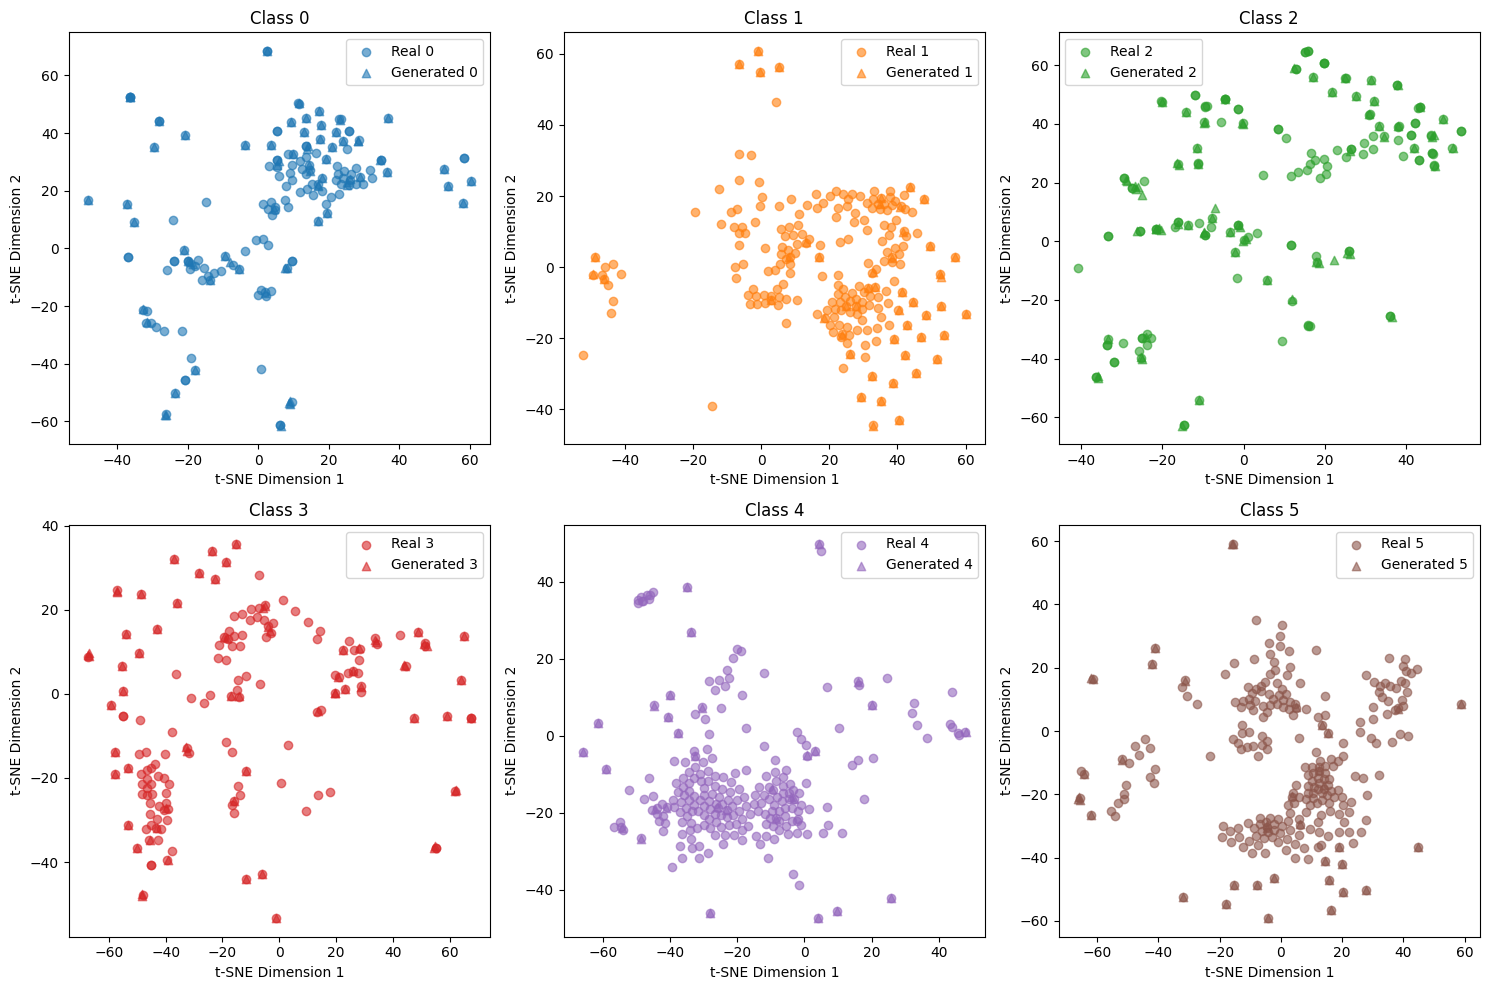

In [ ]:
# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=20, random_state=42)
tsne_results = tsne.fit_transform(oversampled_images)

# Define colors for each class
unique_classes = np.unique(oversampled_labels)
colors = sns.color_palette("tab10", len(unique_classes))

# Create subplots to accommodate all unique classes
num_classes = len(unique_classes)
num_cols = 3  # Number of columns in the subplot grid
num_rows = math.ceil(num_classes / num_cols)  # Calculate the required number of rows

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 5 * num_rows))  # Adjust figsize as needed
axes = axes.flatten()  # Flatten the axes array for easier iteration

# Iterate over each class, ensuring you stay within the bounds of the axes array
for i, cls in enumerate(unique_classes):
    if i < len(axes):  # Check if current class index is within the axes array bounds
        # Select indices for real and synthetic samples per class
        real_indices = np.where((oversampled_labels[:original_size] == cls))[0]
        synthetic_indices_cls = np.where((oversampled_labels[synthetic_indices] == cls))[0] + original_size

        # Scatter original images with circles
        axes[i].scatter(tsne_results[real_indices, 0], tsne_results[real_indices, 1],
                        c=[colors[i]], label=f"Real {cls}", marker='o', alpha=0.6)

        # Scatter synthetic images with triangles
        axes[i].scatter(tsne_results[synthetic_indices_cls, 0], tsne_results[synthetic_indices_cls, 1],
                        c=[colors[i]], label=f"Generated {cls}", marker='^', alpha=0.6)

        # Customize subplot
        axes[i].set_xlabel("t-SNE Dimension 1")
        axes[i].set_ylabel("t-SNE Dimension 2")
        axes[i].set_title(f"Class {cls}")
        axes[i].legend()  # Add legend to each subplot
    else:
        print(f"Skipping plotting for class {cls} due to insufficient subplots.")

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [ ]:
def fetch_one_image_per_class(image_data, labels, num_classes=6):
    # Initialize a dictionary to store the first image of each class
    class_images = {i: {'pre': None, 'post': None, 'topo': None, 'mask': None} for i in range(num_classes)}

    real_pre, real_post, real_topo, real_mask = image_data[:, :, :, :6], image_data[:, :, :, 6:12], image_data[:, :, :, 12:18], image_data[:, :, :, 18:]  # Unpack the image data
    # Iterate over the batch
    for i in range(real_pre.shape[0]):
        # Get the class label for the current image
        class_label = labels[i]  # Assuming labels are integers

        # Check if we have already fetched an image for this class
        if class_images[class_label]['pre'] is None:
            # If not, store the images for this class
            class_images[class_label]['pre'] = real_pre[i]
            class_images[class_label]['post'] = real_post[i]
            class_images[class_label]['topo'] = real_topo[i]
            class_images[class_label]['mask'] = real_mask[i]

        # Once we have one image per class, we can stop (early exit)
        if all(class_images[i]['pre'] is not None for i in range(num_classes)):
            return class_images
    # If the loop completes without finding one image per class, return the images found
    return class_images

def plot_images(image_data, labels, generated_samples, num_classes=6, num_samples=3):

    # Fetch one image per class from the entire dataset
    class_images = fetch_one_image_per_class(image_data, labels)
    print(class_images)

    # Create a figure with 28 rows (7 classes * 4 subplots) and 4 columns
    fig, axes = plt.subplots(num_classes * 4, 4, figsize=(15, 21 * 4))

    # Iterate over each class
    for class_idx in range(num_classes):
        # Fetch the real images for the current class
        class_real_pre = class_images[class_idx]['pre']
        class_real_post = class_images[class_idx]['post']
        class_real_topo = class_images[class_idx]['topo']
        class_real_mask = class_images[class_idx]['mask']

        # Generate images
        pre_channels = 6
        post_channels = 6
        topo_channels = 6
        mask_channels = 1

        gen_pre = generated_samples[:, :, :, :pre_channels]
        gen_post = generated_samples[:, :, :, pre_channels:pre_channels+post_channels]
        gen_topo = generated_samples[:, :, :, pre_channels+post_channels:pre_channels+post_channels+topo_channels]
        gen_mask = generated_samples[:, :, :, pre_channels+post_channels+topo_channels:]

        # Plot real and generated images for the current class
        # Image type: Pre-event
        axes[class_idx * 4, 0].imshow(class_real_pre[:, :, :3])  # Ensure scaling
        axes[class_idx * 4, 0].axis("off")
        axes[class_idx * 4, 0].set_title(f"Class {class_idx} - Real Pre", fontsize=10)
        for sample_idx in range(num_samples):
            axes[class_idx * 4, sample_idx + 1].imshow(gen_pre[sample_idx, :, :, :3])
            axes[class_idx * 4, sample_idx + 1].axis("off")
            axes[class_idx * 4, sample_idx + 1].set_title(f"Sample {sample_idx + 1}", fontsize=8)

        # Image type: Post-event
        axes[class_idx * 4 + 1, 0].imshow(class_real_post[:, :, :3] )  # Ensure scaling
        axes[class_idx * 4 + 1, 0].axis("off")
        axes[class_idx * 4 + 1, 0].set_title(f"Class {class_idx} - Real Post", fontsize=10)
        for sample_idx in range(num_samples):
            axes[class_idx * 4 + 1, sample_idx + 1].imshow(gen_post[sample_idx, :, :, :3])
            axes[class_idx * 4 + 1, sample_idx + 1].axis("off")
            axes[class_idx * 4 + 1, sample_idx + 1].set_title(f"Sample {sample_idx + 1}", fontsize=8)

        # Image type: Topography
        axes[class_idx * 4 + 2, 0].imshow(class_real_topo[:, :, :3])  # Ensure scaling
        axes[class_idx * 4 + 2, 0].axis("off")
        axes[class_idx * 4 + 2, 0].set_title(f"Class {class_idx} - Real Topo", fontsize=10)
        for sample_idx in range(num_samples):
            axes[class_idx * 4 + 2, sample_idx + 1].imshow(gen_topo[sample_idx, :, :, :3])
            axes[class_idx * 4 + 2, sample_idx + 1].axis("off")
            axes[class_idx * 4 + 2, sample_idx + 1].set_title(f"Sample {sample_idx + 1}", fontsize=8)

        # Image type: Mask
        axes[class_idx * 4 + 3, 0].imshow((class_real_mask[:, :, 0]), cmap='gray')
        axes[class_idx * 4 + 3, 0].axis("off")
        axes[class_idx * 4 + 3, 0].set_title(f"Class {class_idx} - Real Mask", fontsize=10)
        for sample_idx in range(num_samples):
            #normalize value of landslide between 0 and 1
            gen_mask = np.where(gen_mask < 0.5, 0, gen_mask)
            gen_mask = np.where(gen_mask >= 0.5, 1, gen_mask)
            axes[class_idx * 4 + 3, sample_idx + 1].imshow(gen_mask[sample_idx, :, :, 0], cmap='gray')
            axes[class_idx * 4 + 3, sample_idx + 1].axis("off")
            axes[class_idx * 4 + 3, sample_idx + 1].set_title(f"Sample {sample_idx + 1}", fontsize=8)

    plt.tight_layout()
    plt.show()
    plt.close()
plot_images(images, label_train, synthetic_images_reshaped, num_classes=6, num_samples=3)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
del oversampled_images_reshaped

In [ ]:
def compute_indices(img):

    B4, B3, B2, B8, B11, _ = img[..., 0], img[..., 1], img[..., 2], img[..., 3], img[..., 4], img[..., 5]
    # Compute NDVI
    ndvi = (B8 - B4) / (B8 + B4 + 1e-6)
    # Compute NDWI
    ndwi = (B3 - B8) / (B3 + B8 + 1e-6)
    # Compute Brightness Index (BI)
    bi = np.sqrt((B4**2 + B3**2 + B2**2) / 3)
    # Compute BSI
    bsi = ((B4 + B11) - (B2 + B8)) / ((B4 + B11) + (B2 + B8) + 1e-6)
    # Compute SAVI (using L = 0.5)
    savi = ((B8 - B4) * 1.5) / (B8 + B4 + 0.5 + 1e-6)
    # Stack the new indices as additional channels
    img_with_indices = np.dstack([img, ndvi, ndwi, bi, bsi, savi])
    return img_with_indices

In [ ]:
# Generate images
pre_channels = 6
post_channels = 6
topo_channels = 6
mask_channels = 1

gen_image_train_pre = synthetic_images_reshaped[:, :, :, :pre_channels]
gen_image_train_post = synthetic_images_reshaped[:, :, :, pre_channels:pre_channels+post_channels]
gen_image_train_topo = synthetic_images_reshaped[:, :, :, pre_channels+post_channels:pre_channels+post_channels+topo_channels]
gen_image_train_mask = synthetic_images_reshaped[:, :, :, pre_channels+post_channels+topo_channels:]
val, counts = np.unique(gen_image_train_mask, return_counts=True)
print(val, counts)

[0.00000000e+00 3.89079942e-04 7.78765825e-04 3.50836175e-03
 6.54565357e-03 7.06630526e-03 7.78844068e-03 7.85766914e-03
 1.12712691e-02 1.32649615e-02 1.34432865e-02 1.59662515e-02
 1.62253082e-02 1.66226327e-02 1.67691149e-02 2.16351449e-02
 2.21942738e-02 2.22925358e-02 2.30624247e-02 2.36068554e-02
 2.62444820e-02 2.66996231e-02 3.05391755e-02 3.13132927e-02
 3.13694887e-02 3.23255099e-02 3.43679674e-02 3.43885198e-02
 3.88279743e-02 4.06491160e-02 4.15394753e-02 4.44905646e-02
 4.52272892e-02 4.64504138e-02 4.66656648e-02 4.89499457e-02
 5.38678877e-02 5.43823950e-02 5.64115793e-02 5.77982441e-02
 6.05010577e-02 6.12086914e-02 6.13438115e-02 6.14472926e-02
 6.17588051e-02 6.25037029e-02 6.50515929e-02 7.28409290e-02
 7.33411312e-02 7.70726204e-02 7.80072436e-02 8.19338039e-02
 8.32200274e-02 8.60727206e-02 9.06064361e-02 9.06796008e-02
 9.37911198e-02 9.44097713e-02 9.70836878e-02 9.71073806e-02
 9.96339098e-02 1.02789991e-01 1.05172649e-01 1.06716983e-01
 1.08244590e-01 1.096599

In [ ]:
#normalize value of landslide between 0 and 1
gen_image_train_mask = np.where(gen_image_train_mask < 0.5, 0, gen_image_train_mask)
gen_image_train_mask = np.where(gen_image_train_mask >= 0.5, 1, gen_image_train_mask)
val, counts = np.unique(gen_image_train_mask, return_counts=True)
print(val, counts)

[0. 1.] [21042474   453334]


In [ ]:
gen_image_train_mask = gen_image_train_mask.astype(np.float64)

In [ ]:
image_train_pre = np.concatenate((image_train_pre, remaining_train_pre), axis=0)
image_train_post = np.concatenate((image_train_post, remaining_train_post), axis=0)
image_train_topo = np.concatenate((image_train_topo, remaining_train_topo), axis=0)
image_train_mask = np.concatenate((image_train_mask, remaining_train_mask), axis=0)
label_train = np.concatenate((label_train, remaining_label_train), axis=0)

image_valid_pre = np.concatenate((image_valid_pre, remaining_valid_pre), axis=0)
image_valid_post = np.concatenate((image_valid_post, remaining_valid_post), axis=0)
image_valid_topo = np.concatenate((image_valid_topo, remaining_valid_topo), axis=0)
image_valid_mask = np.concatenate((image_valid_mask, remaining_valid_mask), axis=0)
label_valid = np.concatenate((label_valid, remaining_label_valid), axis=0)

image_test_pre = np.concatenate((image_test_pre, remaining_test_pre), axis=0)
image_test_post = np.concatenate((image_test_post, remaining_test_post), axis=0)
image_test_topo = np.concatenate((image_test_topo, remaining_test_topo), axis=0)
image_test_mask = np.concatenate((image_test_mask, remaining_test_mask), axis=0)
label_test = np.concatenate((label_test, remaining_label_test), axis=0)

In [ ]:
# For gen_image_train_pre
gen_image_train_pre_with_indices = []
for img in gen_image_train_pre:
    img_with_indices = compute_indices(img)
    gen_image_train_pre_with_indices.append(img_with_indices)

gen_image_train_pre = np.array(gen_image_train_pre_with_indices)

# For gen_image_train_post
gen_image_train_post_with_indices = []
for img in gen_image_train_post:
    img_with_indices = compute_indices(img)
    gen_image_train_post_with_indices.append(img_with_indices)

gen_image_train_post = np.array(gen_image_train_post_with_indices)
print(gen_image_train_pre.shape)
print(gen_image_train_post.shape)

(328, 256, 256, 11)
(328, 256, 256, 11)


In [ ]:
print(gen_image_train_pre.dtype)
print(gen_image_train_post.dtype)

float32
float32


In [ ]:
# For image_train_pre
image_train_pre_with_indices = []
for img in image_train_pre:
    img_with_indices = compute_indices(img)
    image_train_pre_with_indices.append(img_with_indices)

image_train_pre = np.array(image_train_pre_with_indices)

# For image_train_post
image_train_post_with_indices = []
for img in image_train_post:
    img_with_indices = compute_indices(img)
    image_train_post_with_indices.append(img_with_indices)

image_train_post = np.array(image_train_post_with_indices)
print(image_train_pre.shape)
print(image_train_post.shape)

(2443, 256, 256, 11)
(2443, 256, 256, 11)


In [ ]:
print(image_train_pre.dtype)
print(image_train_post.dtype)

float32
float32


In [ ]:
# For gen_image_train_pre
image_valid_pre_with_indices = []
for img in image_valid_pre:
    img_with_indices = compute_indices(img)
    image_valid_pre_with_indices.append(img_with_indices)

image_valid_pre = np.array(image_valid_pre_with_indices)

# For gen_image_train_post
image_valid_post_with_indices = []
for img in image_valid_post:
    img_with_indices = compute_indices(img)
    image_valid_post_with_indices.append(img_with_indices)

image_valid_post = np.array(image_valid_post_with_indices)
print(image_valid_pre.shape)
print(image_valid_post.shape)

(488, 256, 256, 11)
(488, 256, 256, 11)


In [ ]:
# For gen_image_train_pre
image_test_pre_with_indices = []
for img in image_test_pre:
    img_with_indices = compute_indices(img)
    image_test_pre_with_indices.append(img_with_indices)

image_test_pre = np.array(image_test_pre_with_indices)

# For gen_image_train_post
image_test_post_with_indices = []
for img in image_test_post:
    img_with_indices = compute_indices(img)
    image_test_post_with_indices.append(img_with_indices)

image_test_post = np.array(image_test_post_with_indices)
print(image_test_pre.shape)
print(image_test_post.shape)

(327, 256, 256, 11)
(327, 256, 256, 11)


In [ ]:
print(image_train_pre.dtype)
print(image_train_post.dtype)
print(image_train_topo.dtype)
print(image_train_mask.dtype)
print(gen_image_train_mask.dtype)

float32
float32
float32
float64
float64


In [ ]:
print(image_train_pre.min(), image_train_pre.max())
print(image_train_post.min(), image_train_post.max())
print(image_train_topo.min(), image_train_topo.max())
print(image_train_mask.min(), image_train_mask.max())

-0.99999875 1.0
-0.99999887 1.0
0.0 1.0
0.0 1.0


In [ ]:
#Normalization of the Dataset between 0 and 1
def normalize_channels(data, channels_to_normalize, nodata_value=np.nan):
    """
    Normalize specific channels of the dataset to a range of 0 to 1.

    Parameters:
    - data: 4D numpy array of shape (num_samples, height, width, num_channels)
    - channels_to_normalize: list of channel indices that need normalization

    Returns:
    - normalized_data: 4D numpy array with normalized channels
    """
    normalized_data = data.copy()

    for i in range(len(normalized_data)):
        for j in channels_to_normalize:
            # Get the channel data
            channel_data = normalized_data[i, :, :, j]
            # Create a mask for valid data (i.e., data that is not nodata)
            valid_mask = ~np.isnan(channel_data) if np.isnan(nodata_value) else (channel_data != nodata_value)
            # Normalize only the valid data
            if np.any(valid_mask):  # Proceed only if there are valid values
                min_val = channel_data[valid_mask].min()
                max_val = channel_data[valid_mask].max()
                # Avoid division by zero if all values in the channel are the same
                range_val = max_val - min_val
                if range_val != 0:
                    channel_data[valid_mask] = (channel_data[valid_mask] - min_val) / range_val
                else:
                    channel_data[valid_mask] = 0  # Set all valid values to 0 if they are constant

            # Assign the normalized channel data back to the array
            normalized_data[i, :, :, j] = channel_data

    return normalized_data

def get_channels_to_normalize(total_channels, exclude_indices):
    """
    Parameters:
    - total_channels: Total number of channels in the dataset.
    - exclude_indices: List of channel indices that should not be normalized.

    Returns:
    - channels_to_normalize: List of channel indices to normalize.
    """
    return [i for i in range(total_channels) if i not in exclude_indices]

In [ ]:
# Example usage:
total_channels = gen_image_train_pre.shape[-1]  # Number of channels in the dataset
exclude_indices = [0,1,2,3,4,5]  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
gen_image_train_pre = normalize_channels(gen_image_train_pre, channels_to_normalize)
gen_image_train_post = normalize_channels(gen_image_train_post, channels_to_normalize)

In [ ]:
# Example usage:
total_channels = image_valid_pre[0].shape[-1]  # Number of channels in the dataset
exclude_indices = [0,1,2,3,4,5]  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
image_valid_pre = normalize_channels(image_valid_pre, channels_to_normalize)
image_valid_post = normalize_channels(image_valid_post, channels_to_normalize)

In [ ]:
# Example usage:
total_channels = image_train_pre.shape[-1]  # Number of channels in the dataset
exclude_indices = [0,1,2,3,4,5]  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
image_train_pre = normalize_channels(image_train_pre, channels_to_normalize)
image_train_post = normalize_channels(image_train_post, channels_to_normalize)

In [ ]:
# Example usage:
total_channels = image_test_pre[0].shape[-1]  # Number of channels in the dataset
exclude_indices = [0,1,2,3,4,5]  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
image_test_pre = normalize_channels(image_test_pre, channels_to_normalize)
image_test_post = normalize_channels(image_test_post, channels_to_normalize)

In [ ]:
# Create an array of indices to represent the order of the data
indices = np.arange(image_train_topo.shape[0])

# Shuffle the indices randomly
np.random.shuffle(indices)

# Use the shuffled indices to reorder the datasets
image_train_pre = image_train_pre[indices]
image_train_post = image_train_post[indices]
image_train_topo = image_train_topo[indices]
image_train_mask = image_train_mask[indices]
label_train = label_train[indices]

print(image_train_pre.dtype)
print(image_train_post.dtype)
print(image_train_topo.dtype)
print(image_train_mask.dtype)

float32
float32
float32
float64


In [ ]:
# Recombine the split data for each image type into tuples
image_train = (image_train_pre, image_train_post, image_train_topo, image_train_mask)
image_valid = (image_valid_pre, image_valid_post, image_valid_topo, image_valid_mask)
image_test = (image_test_pre, image_test_post, image_test_topo, image_test_mask)

In [ ]:
print(image_train[0].shape)
print(image_train[1].shape)
print(image_train[2].shape)
print(image_train[3].shape)

(2771, 256, 256, 11)
(2771, 256, 256, 11)
(2771, 256, 256, 6)
(2771, 256, 256, 1)


In [ ]:
print(image_train[0].min(), image_train[0].max())
print(image_train[1].min(), image_train[1].max())
print(image_train[2].min(), image_train[2].max())
print(image_train[3].min(), image_train[3].max())

0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0


In [ ]:
# Visualise some data
import random
img= random.randint(0, len(image_train[0]))

fig,(ax1,ax2)= plt.subplots(2,10,figsize=(30,10))

ax1[0].set_title("Post RGB")
ax1[0].title.set_fontsize(20)
ax1[1].set_title("Post NIR")
ax1[1].title.set_fontsize(20)
ax1[2].set_title("Post SWIR1")
ax1[2].title.set_fontsize(20)
ax1[3].set_title("Post SWIR2")
ax1[3].title.set_fontsize(20)
ax1[4].set_title("Post NDVI")
ax1[4].title.set_fontsize(20)
ax1[5].set_title("Post NDWI")
ax1[5].title.set_fontsize(20)
ax1[6].set_title("Post BI")
ax1[6].title.set_fontsize(20)
ax1[7].set_title("Post BSI")
ax1[7].title.set_fontsize(20)
ax1[8].set_title("Post SAVI")
ax1[8].title.set_fontsize(20)
ax1[9].set_title("Mask")
ax1[9].title.set_fontsize(20)
ax1[0].imshow(image_train[0][img, :, :, :3])
ax1[1].imshow(image_train[0][img, :, :, 3])
ax1[2].imshow(image_train[0][img, :, :, 4])
ax1[3].imshow(image_train[0][img, :, :, 5])
ax1[4].imshow(image_train[0][img, :, :, 6])
ax1[5].imshow(image_train[0][img, :, :, 7])
ax1[6].imshow(image_train[0][img, :, :, 8])
ax1[7].imshow(image_train[0][img, :, :, 9])
ax1[8].imshow(image_train[0][img, :, :, 10])
ax1[9].imshow(image_train[3][img, :, :, 0])
ax1[0].set(xticks=[], yticks=[])
ax1[1].set(xticks=[], yticks=[])
ax1[2].set(xticks=[], yticks=[])
ax1[3].set(xticks=[], yticks=[])
ax1[4].set(xticks=[], yticks=[])
ax1[5].set(xticks=[], yticks=[])
ax1[6].set(xticks=[], yticks=[])
ax1[7].set(xticks=[], yticks=[])
ax1[8].set(xticks=[], yticks=[])
ax1[9].set(xticks=[], yticks=[])
plt.tight_layout()

ax2[0].set_title("Pre RGB")
ax2[0].title.set_fontsize(20)
ax2[1].set_title("Pre NIR")
ax2[1].title.set_fontsize(20)
ax2[2].set_title("Pre SWIR1")
ax2[2].title.set_fontsize(20)
ax2[3].set_title("Pre SWIR2")
ax2[3].title.set_fontsize(20)
ax2[4].set_title("Pre NDVI")
ax2[4].title.set_fontsize(20)
ax2[5].set_title("Pre NDWI")
ax2[5].title.set_fontsize(20)
ax2[6].set_title("Pre BI")
ax2[6].title.set_fontsize(20)
ax2[7].set_title("Pre BSI")
ax2[7].title.set_fontsize(20)
ax2[8].set_title("Pre SAVI")
ax2[8].title.set_fontsize(20)
ax2[9].set_title("DSM+Slope")
ax2[9].title.set_fontsize(20)
ax2[0].imshow(image_train[1][img, :, :, :3])
ax2[1].imshow(image_train[1][img, :, :, 3])
ax2[2].imshow(image_train[1][img, :, :, 4])
ax2[3].imshow(image_train[1][img, :, :, 5])
ax2[4].imshow(image_train[1][img, :, :, 6])
ax2[5].imshow(image_train[1][img, :, :, 7])
ax2[6].imshow(image_train[1][img, :, :, 8])
ax2[7].imshow(image_train[1][img, :, :, 9])
ax2[8].imshow(image_train[1][img, :, :, 10])
ax2[9].imshow(image_train[2][img, :, :, :3])
ax2[0].set(xticks=[], yticks=[])
ax2[1].set(xticks=[], yticks=[])
ax2[2].set(xticks=[], yticks=[])
ax2[3].set(xticks=[], yticks=[])
ax2[4].set(xticks=[], yticks=[])
ax2[5].set(xticks=[], yticks=[])
ax2[6].set(xticks=[], yticks=[])
ax2[7].set(xticks=[], yticks=[])
ax2[8].set(xticks=[], yticks=[])
ax2[9].set(xticks=[], yticks=[])
plt.tight_layout()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
print(image_train[0].dtype)
print(image_train[1].dtype)
print(image_train[2].dtype)
print(image_train[3].dtype)

float32
float32
float32
float64


In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_pre_train.npy", image_train[0])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_pre_val.npy", image_valid[0])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_pre_test.npy", image_test[0])

In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_post_train.npy", image_train[1])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_post_val.npy", image_valid[1])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_post_test.npy", image_test[1])

In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_topo_train.npy", image_train[2])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_topo_val.npy", image_valid[2])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/X_aug_topo_test.npy", image_test[2])

In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/Y_aug_mask_train.npy", image_train[3])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/Y_aug_mask_val.npy", image_valid[3])
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/Y_aug_mask_test.npy", image_test[3])

In [ ]:
# Assuming 'label_train', 'label_valid', and 'label_test' are your label arrays
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/label_aug_train.npy", label_train)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/label_aug_valid.npy", label_valid)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data2/label_aug_test.npy", label_test)

## Process The dataset with Ordinary augmentation

In [ ]:
X_train1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_genpre_train.npy")
X_val1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_genpre_val.npy")
X_test1 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_genpre_test.npy")

In [ ]:
X_train2 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_post_train.npy")
X_val2 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_post_val.npy")
X_test2 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_post_test.npy")

In [ ]:
X_train3 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_topo_train.npy")
X_val3 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_topo_val.npy")
X_test3 = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/X_topo_test.npy")

In [ ]:
y_train = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Y_mask_train.npy")
y_val = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Y_mask_val.npy")
y_test = np.load(f"/content/drive/MyDrive/landslide/Data/Arrays/Y_mask_test.npy")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Define augmentation parameters
augmentation_params = {
    'zoom_range': 0.1,
    'rotation_range': 90,
    'shear_range': 0.1,
    'fill_mode': 'nearest'
}

# Create an ImageDataGenerator instance for spatial augmentations
spatial_datagen = ImageDataGenerator(**augmentation_params)


# Define the partition sizes and target augmentation sizes
partition_sizes = [512, 150, 212, 150, 150, 238, 252, 302, 477]
target_sizes = [512, 220, 260, 220, 220, 270, 290, 302, 477]

# Function to augment all datasets consistently
def augment_datasets(X1, X2, X3, y):
    augmented_X1 = []
    augmented_X2 = []
    augmented_X3 = []
    augmented_y = []

    start_index = 0
    for partition_size, target_size in zip(partition_sizes, target_sizes):
        end_index = start_index + partition_size
        num_augmentations = target_size - partition_size

        if num_augmentations > 0:
            # Generate random indices for consistent augmentation
            random_indices = np.random.choice(np.arange(partition_size), size=num_augmentations, replace=False)

            for i in random_indices:
                # Spatial augmentations (applied to all datasets)

                # Reshape data for ImageDataGenerator (add batch dimension)
                X1_image = X1[start_index + i].reshape((1,) + X1[start_index + i].shape)
                X2_image = X2[start_index + i].reshape((1,) + X2[start_index + i].shape)
                X3_image = X3[start_index + i].reshape((1,) + X3[start_index + i].shape)
                y_image = y[start_index + i].reshape((1,) + y[start_index + i].shape)

                # Apply spatial augmentations using the same seed
                seed = np.random.randint(0, 1000)  # Use a random seed for each augmentation

                X1_augmented = next(spatial_datagen.flow(X1_image, batch_size=1, seed=seed))[0]
                X2_augmented = next(spatial_datagen.flow(X2_image, batch_size=1, seed=seed))[0]
                X3_augmented = next(spatial_datagen.flow(X3_image, batch_size=1, seed=seed))[0]
                y_augmented = next(spatial_datagen.flow(y_image, batch_size=1, seed=seed))[0]

                augmented_X1.append(X1_augmented)
                augmented_X2.append(X2_augmented)
                augmented_X3.append(X3_augmented)
                augmented_y.append(y_augmented)

        # Add original partition data
        augmented_X1.extend(X1[start_index:end_index])
        augmented_X2.extend(X2[start_index:end_index])
        augmented_X3.extend(X3[start_index:end_index])
        augmented_y.extend(y[start_index:end_index])

        start_index = end_index

    return np.array(augmented_X1), np.array(augmented_X2), np.array(augmented_X3), np.array(augmented_y)


# Augment all datasets consistently
X_train1, X_train2,  X_train3, y_train = augment_datasets(X_train1, X_train2, X_train3, y_train)

/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:619: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3, or 4 channels on axis 3. However, it was passed an array with shape (1, 256, 256, 11) (11 channels).
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:619: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3, or 4 channels on axis 3. However, it was passed an array with shape (1, 256, 256, 6) (6 channels).
  warnings.warn(


In [ ]:
print("Shape of the training dataset (OPTICAL Post image): ", X_train1.shape)
print("Shape of the training dataset (OPTICAL Pre image): ", X_train2.shape)
print("Shape of the training dataset (OPTICAL DEM image): ", X_train3.shape)
print("Shape of the training dataset (label image): ",y_train.shape)

Shape of the training dataset (OPTICAL Post image):  (2771, 256, 256, 11)
Shape of the training dataset (OPTICAL Pre image):  (2771, 256, 256, 11)
Shape of the training dataset (OPTICAL DEM image):  (2771, 256, 256, 6)
Shape of the training dataset (label image):  (2771, 256, 256, 1)


In [ ]:
print(X_train1.min(), X_train1.max(),X_train2.min(), X_train2.max(),X_train3.min(), X_train3.max(),y_train.min(), y_train.max())

0.0 1.0 0.0 1.0 0.0 1.0 0.0 1.0


In [ ]:
# Create an array of indices to represent the order of the data
indices = np.arange(X_train1.shape[0])

# Shuffle the indices randomly
np.random.shuffle(indices)

# Use the shuffled indices to reorder the datasets
X_train1 = X_train1[indices]
X_train2 = X_train2[indices]
X_train3 = X_train3[indices]
y_train = y_train[indices]

In [ ]:
print(X_train1.dtype)
print(X_train2.dtype)
print(X_train3.dtype)
print(y_train.dtype)

float32
float32
float32
float64


In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_pre_train.npy", X_train1)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_post_train.npy", X_train2)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_topo_train.npy", X_train3)

In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_pre_val.npy", X_val1)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_post_val.npy", X_val2)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_topo_val.npy", X_val3)

In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_pre_test.npy", X_test1)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_post_test.npy", X_test2)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data1/X_aug_topo_test.npy", X_test3)

In [ ]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data1/Y_aug_mask_train.npy", y_train)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data1/Y_aug_mask_val.npy", y_val)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Data1/Y_aug_mask_test.npy", y_test)